['bf8da848-a_PREM_____Resovsky_____unif_asth_non_asth_____VM7_unif_lm--\\a', '_1.60e-01--\\Delta^{ASTHENOSPHERE_0}_3.00e+00--\\eta_m^{MANTLE-ASTHENOSPHERE_0}_2.00e+19--\\eta_m^{LOWER-MANTLE_0}_1.00e+21.json']
['bf8da848-a_PREM_____Resovsky_____unif_asth_non_asth_____VM7_unif_lm--\\alpha^{ASTHENOSPHERE_0}_1.60e-01--\\D', '_3.00e+00--\\eta_m^{MANTLE-ASTHENOSPHERE_0}_2.00e+19--\\eta_m^{LOWER-MANTLE_0}_1.00e+21.json']
['bf8da848-a_PREM_____Resovsky_____unif_asth_non_asth_____VM7_unif_lm--\\a', '_1.60e-01--\\Delta^{ASTHENOSPHERE_0}_3.00e+00--\\eta_m^{MANTLE-ASTHENOSPHERE_0}_2.00e+19--\\eta_m^{LOWER-MANTLE_0}_1.00e+22.json']
['bf8da848-a_PREM_____Resovsky_____unif_asth_non_asth_____VM7_unif_lm--\\alpha^{ASTHENOSPHERE_0}_1.60e-01--\\D', '_3.00e+00--\\eta_m^{MANTLE-ASTHENOSPHERE_0}_2.00e+19--\\eta_m^{LOWER-MANTLE_0}_1.00e+22.json']
['bf8da848-a_PREM_____Resovsky_____unif_asth_non_asth_____VM7_unif_lm--\\a', '_1.60e-01--\\Delta^{ASTHENOSPHERE_0}_3.00e+00--\\eta_m^{MANTLE-ASTHENOSPHERE_0}_4.50e+

/tmp/ipykernel_196853/4290867011.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  tight_layout()


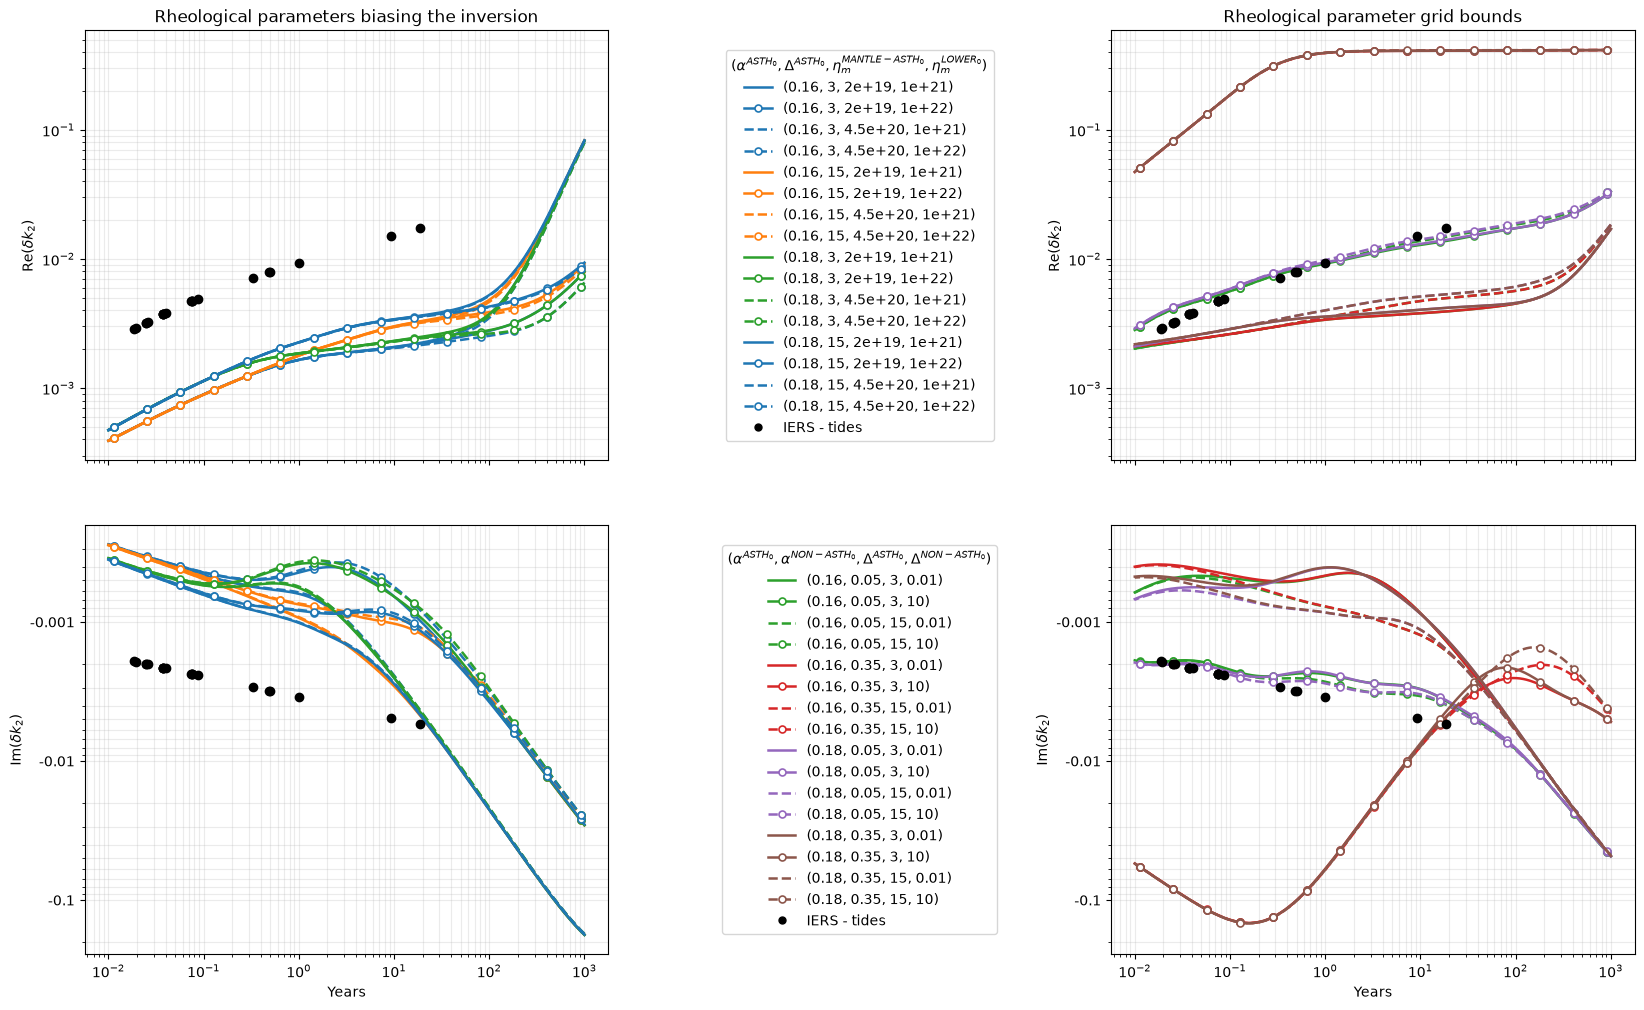

In [1]:
from alna import load_love_numbers_for_gins
from base_models import lagrange_order4
from numpy import linspace, exp, ndindex, ndarray, log
from matplotlib.pyplot import subplots, show, tight_layout
from numpy import array
from alna.tide_correction_model import REFERENCE_K2, IERS_LONG_PERIOD_ZONAL_TIDES,tide_angular_frequencies_to_cycle_per_yr
from matplotlib import colormaps
from matplotlib.lines import Line2D

k2_reference = array(
    [
        REFERENCE_K2 + delta_k2_r + 1j * k2_i
        for _, _, delta_k2_r, k2_i in IERS_LONG_PERIOD_ZONAL_TIDES
    ],
    dtype=complex,
)

N_FREQ_PLOT = 1000

fig = subplots(figsize=(20, 12))[0]
fig.clear()

gs = fig.add_gridspec(
    2,
    3,
    width_ratios=(1, 0.4, 1),
    wspace=0.35,
    hspace=0.15,
)

ax_real_left = fig.add_subplot(gs[0, 0])
ax_imag_left = fig.add_subplot(gs[1, 0], sharex=ax_real_left)
ax_real_right = fig.add_subplot(gs[0, 2], sharex=ax_real_left, sharey=ax_real_left)
ax_imag_right = fig.add_subplot(gs[1, 2], sharex=ax_real_left, sharey=ax_imag_left)

legend_axes = [
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 1]),
]

for ax in legend_axes:
    ax.set_axis_off()

groups = [
    ("varying_biasing", ax_real_left, ax_imag_left),
    ("varying_mantle", ax_real_right, ax_imag_right),
]

TITLE_MAP = {
    "varying_biasing": "Rheological parameters biasing the inversion",
    "varying_mantle": "Rheological parameter grid bounds",
}

tide_periods = 1 / tide_angular_frequencies_to_cycle_per_yr()

for group, (directory, ax_real, ax_imag) in enumerate(groups):
    tabs, log_frequencies, elastic_love_numbers, anelastic_love_numbers, _ = (
        load_love_numbers_for_gins(directory=directory)
    )

    perturbations: ndarray = anelastic_love_numbers[..., 0, :] - elastic_love_numbers[0]
    new_log_frequencies = linspace(log(0.001), log_frequencies[-1], N_FREQ_PLOT)
    years = exp(-new_log_frequencies)

    n_colors = perturbations.shape[0] * perturbations.shape[1]
    palette = colormaps["tab10"].colors[:3] if group == 0 else colormaps["tab10"].colors[2:6]

    markers = ("", "o", "^", "s", "D", "v", "P", "X", "<", ">")
    line_styles = ("-", "--", "-.", ":")

    for index in ndindex(perturbations.shape[:-1]):
        parameters = tuple(values[i].item() for values, i in zip(tabs.values(), index))
        color_index = index[0] * perturbations.shape[1] + index[1]

        style = dict(
            color=palette[color_index % len(palette)],
            linestyle=line_styles[index[2] % len(line_styles)],
            marker=markers[index[3] % len(markers)],
            linewidth=1.8,
            alpha=1,
            markersize=5,
            markerfacecolor="white",
            markeredgewidth=1.2,
            # Sparse, staggered markers keep the curves readable.
            markevery=(8 * index[3], 70),
        )

        for ax, values in (
            (ax_real, perturbations[index].real),
            (ax_imag, -perturbations[index].imag),
        ):
            ax.plot(
                years,
                lagrange_order4(log_frequencies, values, new_log_frequencies),
                label=(
                    "("
                    + ", ".join(
                        f"{10**p if "Delta" in name or "alpha" in name else p:.2g}"
                        for p, name in zip(parameters, tabs.keys())
                    )
                    + ")"
                    if ax is ax_real
                    else None
                ),
                **style,
            )

    ax_real.scatter(
        tide_periods,
        k2_reference.real - elastic_love_numbers[0],
        color="black",
        label="IERS - tides",
        zorder=3,
    )

    ax_imag.scatter(
        tide_periods,
        -k2_reference.imag,
        color="black",
        zorder=3,
    )

    _, labels = ax_real.get_legend_handles_labels()

    handles = [
        Line2D(
            [],
            [],
            color=line.get_color(),
            linestyle=line.get_linestyle(),
            marker=line.get_marker(),
            linewidth=1.8,
            markersize=5,
            markerfacecolor="white",
            markeredgewidth=1.2,
        )
        for line in ax_real.lines
    ]

    handles.append(
        Line2D(
            [],
            [],
            color="black",
            marker="o",
            linestyle="none",
            markersize=5,
        )
    )

    legend_axes[group].legend(
        handles,
        labels,
        title=rf"$({', '.join((parameter_name.replace("ASTHENOSPHERE", "ASTH").replace("-MANTLE", "").replace(r"\log_{10}", "") for parameter_name in tabs.keys()))})$",
        loc="center",
        borderaxespad=0,
    )

    ax_real.set_title(TITLE_MAP[directory])
    ax_real.tick_params(labelbottom=False)
    ax_imag.set_xlabel("Years")

    for ax in (ax_real, ax_imag):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", alpha=0.25)

    ax_real.set_ylabel(r"$\operatorname{Re}(\delta k_2)$")
    ax_imag.set_ylabel(r"$\operatorname{Im}(\delta k_2)$")

ax_imag_left.invert_yaxis()
ax_imag_left.yaxis.set_major_formatter(lambda y, _: f"{-y:g}")

tight_layout()
fig.savefig("k_2_rheology_bounds.pdf")
show()